**Πριν ξεκινήσεις να τρέχεις τον κώδικα**

Κάνε κλικ στο <kbd>Runtime</kbd> στην κορυφή της σελίδας, και στις επιλογές <kbd>change runtime type</kbd> ή <kbd>runtime options</kbd>. Εκεί επίλεξε ένα κουτάκι που λέει <kbd>(T4) GPU</kbd>.

**Πώς χρησιμοποιείς αυτό το αρχείο;**

Αυτό το αρχείο είναι ένα *jupyter notebook*, που αποτελείται από κελιά κειμένου (όπως αυτό) και κελιά κώδικα (όπως το παραπάνω). Μπορείς να τρέξεις τα κελιά κώδικα με <kbd>shift</kbd> + <kbd>enter</kbd>. Πριν προχωρήσεις, είναι σημαντικό να τρέξεις το παραπάνω κελί, ώστε o υπολογιστής να μπορεί να εισάγει όλες τις απαραίτητες συναρτήσεις.


In [1]:
import pip

import numpy as np
import os
from glob import glob
import torch
from PIL import Image
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import torch.nn.functional as F

%pip install medmnist

%pip install SimpleITK
import SimpleITK as sitk


!git clone https://github.com/NicosStarreveld/WorkshopCNNs.git

fatal: destination path 'WorkshopCNNs' already exists and is not an empty directory.


# Τα μαθηματικά πίσω από την ΤΝ - Εφαρμογή: ιατρικά δεδομένα

Τα νευρωνικά δίκτυα (CNNs) μπορούν να χρησιμοποιηθούν για την αυτόματη ερμηνεία εικόνων. Οι υπολογιστές είναι μάλιστα καλύτεροι σε ορισμένες εργασίες ανάλυσης εικόνας από τους ανθρώπους, επειδή οι άνθρωποι έχουν μικρή διάρκεια συγκέντρωσης. Σ' αυτό το εργαστήριο θα ρίξουμε μια ματιά στο πώς ένας υπολογιστής μπορεί να ερμηνεύει εικόνες. Θα εργαστούμε με ένα (δημόσιο) ιατρικό σύνολο δεδομένων και θα εκπαιδεύσουμε το δικό μας δίκτυο που μπορεί να ξεχωρίζει μεταξύ εικόνων δοντιών με και χωρίς απονεύρωση.

### Ψηφιακές εικόνες

Ο υπολογιστής βλέπει μια εικόνα ως έναν μεγάλη πίνακα με αριθμούς, κάθε στοιχείο του πίνακα (γνωστότερο ως *pixel*) περιέχει την τοπική ένταση της εικόνας. Στην περίπτωση μιας έγχρωμης εικόνας, πρόκειται για τρεις πίνακες τον έναν πάνω στον άλλο, που αντιπροσωπεύουν αντίστοιχα το κόκκινο, το μπλε και το πράσινο κανάλι. Στην περίπτωση μιας ασπρόμαυρης εικόνας, η ψηφιακή εικόνα είναι ένας μοναδικός πίνακας με εντάσεις.

In [2]:
#definieert twee functies die je later kan gebruiken om de images te openen en te visualiseren
def open_img(path):
    if path.endswith('.png'):
        return np.array(Image.open(path).convert('L'))
    elif path.endswith('.mhd'):
        return sitk.GetArrayFromImage(sitk.ReadImage(path))[32,:,:] # return 1 slice of the image

def visualize(img, clim=[-300,450]):
    plt.imshow(img, cmap='gray', clim=clim)
    plt.axis('off')
    plt.show()

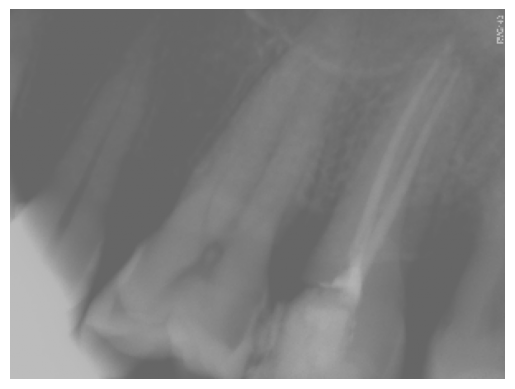

In [3]:
# inladen van beeld van de ribbenkast
# definieer pad naar beeld
# img_path = 'data/ribs/VinDr_RibCXR_train_000.png'
img_path = 'WorkshopCNNs/Xrays_with/167.png'
img = open_img(img_path)
# visualiseer beeld
visualize(img)

In [4]:
print(np.shape(img))

# Hoe veel pixels zijn dit?

(224, 300)


## Convolutional Neural Network

Οι εν λόγω συνελικτικές λειτουργίες αποτελούν τη βάση ενός λεγόμενου συνελικτικού νευρωνικού δικτύου. Στην ουσία, πρόκειται για ένα νευρωνικό δίκτυο που μπορεί να χρησιμοποιηθεί για διάφορες εργασίες υπολογιστικής όρασης, όπως η ταξινόμηση εικόνων, η ανίχνευση αντικειμένων ή ακόμη και ο προσδιορισμός των ακριβών ορίων ενός αντικειμένου σε μια εικόνα. Τα συνελικτικά νευρωνικά δίκτυα αποτελούνται από μια στοίβα συνελικτικών επιπέδων. Εφαρμόζοντας συνεχώς συνελικτικές λειτουργίες μέσα σε μια «στοίβα», ο υπολογιστής μπορεί να εξετάζει μια ολοένα και μεγαλύτερη τοπική περιοχή γύρω από κάθε εικονοστοιχείο (perceptive field). Οι πυρήνες σε όλες αυτές τις συνελικές λειτουργίες δεν καθορίζονται από ανθρώπους, αλλά προσδιορίζονται κατά τη διάρκεια της εκπαίδευσης αυτού του δικτύου. Στην υπόλοιπη ενότητα αυτού του notebook θα δείξουμε ένα μικρό παράδειγμα του πώς λειτουργεί αυτό και πώς μπορούμε να αξιολογήσουμε πόσο καλό είναι το δίκτυο στη συγκεκριμένη εργασία του.

### Τεχνικό βήμα  - ο κώδικας εδώ δεν έχει κάτι ιδιαίτερα ενδιαφέρον για την εφαρμογή

In [5]:
# Φτιάχνω τις εικόνες σε μορφή ώστε να τις διαβάσει το CNN. Αυτό είναι ένα
# τεχνικό βήμα ώστε να μπορεί το πρόγραμμα να επεξεργαστεί τις εικόνες

import cv2
from sklearn.model_selection import train_test_split

images = []
labels = []
orig_images = []

for filename in os.listdir("WorkshopCNNs/Xrays_with"):
  if 'ipynb' in filename: continue
  orig = cv2.imread(f"WorkshopCNNs/Xrays_with/{filename}", cv2.IMREAD_GRAYSCALE)
  img = cv2.resize(orig, (28, 28))
  img = img.astype(np.uint8)

  orig_images.append(orig)
  images.append(img)
  labels.append([1])

for filename in os.listdir("WorkshopCNNs/Xrays_without"):
  if 'ipynb' in filename: continue
  orig = cv2.imread(f"WorkshopCNNs/Xrays_without/{filename}", cv2.IMREAD_GRAYSCALE)
  img = cv2.resize(orig, (28, 28))
  img = img.astype(np.uint8)

  orig_images.append(orig)
  images.append(img)
  labels.append([0])

images = np.array(images)
labels = np.array(labels)
orig_images = np.array(orig_images, dtype=object)

# Split resized images AND original images together
X_train, X_temp, X_train_orig, X_temp_orig, y_train, y_temp = train_test_split( images, orig_images, labels, test_size=0.3 )
X_val, X_test, X_val_orig, X_test_orig, y_val, y_test = train_test_split( X_temp, X_temp_orig, y_temp, test_size=0.5 )

# Opslaan in MedMNIST-formaat
np.savez("teethmnist.npz",
         train_images=X_train, train_labels=y_train, train_orig=X_train_orig,
         val_images=X_val, val_labels=y_val, val_orig=X_val_orig,
         test_images=X_test, test_labels=y_test, test_orig=X_test_orig,)

### Τεχνικό βήμα 2 - ο κώδικας εδώ δεν έχει κάτι ιδιαίτερα ενδιαφέρον για την εφαρμογή (φτιάχνω μια λεγόμενη κλάση στην Python ώστε να μπορώ να εισάγω τις εικόνες στο ΝΝ με αποδοτικό τρόπο)

In [6]:
from torch.utils.data import Dataset

class TeethMNIST(Dataset):
  def __init__(self, split="train", transform=None):
      data = np.load("teethmnist.npz", allow_pickle=True)

      self.images = data[f"{split}_images"]
      self.labels = data[f"{split}_labels"]
      self.orig_images = data[f"{split}_orig"] # original images

      self.transform = transform

  def __len__(self):
      return len(self.images)

  def __getitem__(self, idx):
      img = self.images[idx].astype(np.float32)
      orig = self.orig_images[idx]
      label = int(self.labels[idx])

      # Add channel dimension: (1, H, W)
      img = np.expand_dims(img, axis=0)
      img = torch.tensor(img)

      if self.transform:
          img = self.transform(img)

      return {
          "img": img, # tensor → batched
          "label": label, # scalar → batched
          "orig": orig # numpy → ignored by collate
          }

In [7]:
import medmnist
%pip install monai

### Χωρισμός δεδομένων για εκπαίδευση, επαλήθευση και δοκιμή.

Χρησιμποιοιύμε περίπου το 70% των εικόνων για την εκπαίδευση του CNN, και από 15% για την επαλήθευση και δοκιμή.



In [8]:
import monai
from monai.transforms import NormalizeIntensity

data_transform = NormalizeIntensity(subtrahend=.5, divisor=.5)

train_dataset = TeethMNIST(split="train", transform=data_transform)
val_dataset = TeethMNIST(split="val", transform=data_transform)
test_dataset = TeethMNIST(split="test", transform=data_transform)

val_dataset = TeethMNIST(split="val", transform=data_transform)

def collate_without_orig(batch): # Remove "orig" from every sample before batching
    batch_no_orig = []
    for sample in batch:
        sample = {k: v for k, v in sample.items() if k != "orig"}
        batch_no_orig.append(sample)
    return monai.data.utils.list_data_collate(batch_no_orig)

train_dataloader = monai.data.DataLoader(train_dataset, batch_size=16, shuffle=True,
                                         collate_fn=collate_without_orig)
val_dataloader = monai.data.DataLoader(val_dataset, batch_size = 16, shuffle=False,
                                       collate_fn=collate_without_orig)

print("Χρησιμοποιούμε το ", f"{(len(train_dataset)/(len(train_dataset) + len(val_dataset) + len(test_dataset))*100):.2f}", "%", " των εικόνων για να εκπαιδεύσουμε το ΝΝ.")


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Χρησιμοποιούμε το  69.85 %  των εικόνων για να εκπαιδεύσουμε το ΝΝ.


### Καθρισμός της δομής του CNN

Θα δημιουργήσουμε ένα CNN με τις παρακάτω προδιαγραφές:

<ol>
<li> Η πρώτη στρώση έχει 9216 τεχνητούς νευρώνες. Δεν εισάγουμε ακριβώς την είκονα στο ΤΝΝ, αλλά την εικόνα μετά από το λεγόμενο pooling (δε θα μπούμε σε λεπτομέρειες); </li>
<li> 2 ενδιάμεσες στρώσεις νευρώνων;</li>
<li> στην πρώτη στρώση θα 'μάθει' 32 πυρήνες/φίλτρα;</li>
<li> στη δεύτερη στρώση θα 'μάθει' ακόμα 32 πυρήνες/φίλτρα;</li>
<li> το output είναι 0 ή 1.</li>
</ol>


In [13]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1)
        self.fc1 = nn.Linear(in_features=9216, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=1)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        output = self.fc2(x)
        return output

net = Net()


### Κατασκευή του τεχνητού CNN με όνομα model = Net().  

In [20]:
model = Net()
model.cuda()

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
# loss function: Binary cross entropy (good for classification, see slides).
loss_function = torch.nn.BCEWithLogitsLoss()

In [11]:
from tqdm import tqdm

def train_medmnist(model, train_dataloader, val_dataloader, optimizer, epochs, device='cuda', val_freq=1):
    train_loss = []
    val_loss = []

    for epoch in tqdm(range(epochs)):
        # model in training mode
        model.train()
        steps = 0
        epoch_loss = 0
        for batch in train_dataloader:
            optimizer.zero_grad()
            images = batch['img'].float().to(device)
            labels = batch['label'].float().to(device)
            labels = labels.unsqueeze(1)
            output = model(images)
            # compute the loss between the targets and the outputs in the model
            loss = loss_function(output, labels)
            epoch_loss += loss.item()
            # back propagation, update the weights in the CNN
            loss.backward()
            optimizer.step()
            steps += 1

        train_loss.append(epoch_loss/steps)

        # validation loop
        if epoch % val_freq == 0:
            steps = 0
            val_epoch_loss = 0
            model.eval()
            for batch in val_dataloader:
                images = batch['img'].float().to(device)
                labels = batch['label'].float().to(device)
                labels = labels.unsqueeze(1)
                output = model(images)
                loss = loss_function(output, labels)
                val_epoch_loss += loss.item()
                steps += 1
            val_loss.append(val_epoch_loss/steps)

    # plot the losses together
    plt.plot(train_loss, label='train loss')
    plt.plot(np.arange(0, epochs, val_freq), val_loss, label='val loss')
    plt.legend()
    plt.show()

    return model, train_loss, val_loss

### Eκπαίδευση του τεχνητού CNN  

Τώρα που έχουμε το νευρωνικό δίκτυο και τη συνάρτηση κόστους (loss function), μπορούμε πραγματικά να ξεκινήσουμε την εκπαίδευση του CNN και να μάθει τους πυρήνες που χρειάζεται για να διακρίνει μεταξύ 'υγιών' και 'μη υγιών' ασθενών.

Δύο σημαντικές μεταβλητές στον κώδικα, τις οποίες μπορείτε να τις αλλάξετε. Προσοχή: άμα θέλετε να αλλάξετε αυτές τις τιμές πρέπει πρώτα να τρέξετε το κελί πιο πάνω (model = Net()).

<b>val_freq</b>: κάθε πόσα βήματα κάνουμε <b>validation</b> του CNN.

🧠 Γιατί είναι χρήσιμο;

- Αν κάνεις validation πολύ συχνά, η εκπαίδευση γίνεται πιο αργή.

- Αν κάνεις validation πολύ αραιά, μπορεί να χάσεις πότε αρχίζει το overfitting.

<b>n_epochs</b>:  καθορίζει πόσες φορές το μοντέλο θα δει ολόκληρο το training dataset.

Με άλλα λόγια:

👉 1 epoch = μία πλήρης διέλευση όλων των training images μέσα από το μοντέλο.

Αν έχεις 200 εικόνες και batch size 20:

- 1 epoch = 10 batches
- 5 epochs = 50 batches
- 20 epochs = 200 batches

To batch size δίνει πόσες εικόνες θα "δει" το CNN ταυτόχρονα πριν γίνει μια αναβάθμιση των weights του. Στη δική μας περίπτωση έχουμε επιλέξει batch size ίσο με 32. Δηλαδή το CNN επεξεργάζεται 32 εικόνες ταυτόχρονα, για μικρές βάσεις δεδομένων σαν τη δική μας ίσως να ήταν καλό να επιλέξουμε μικρότερο batch size, ας πούμε 16.

Το μοντέλο μαθαίνει σταδιακά, και κάθε epoch βελτιώνει (συνήθως) την απόδοση.

  0%|          | 0/40 [00:00<?, ?it/s]/tmp/ipykernel_10536/715730075.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])
100%|██████████| 40/40 [00:03<00:00, 12.62it/s]


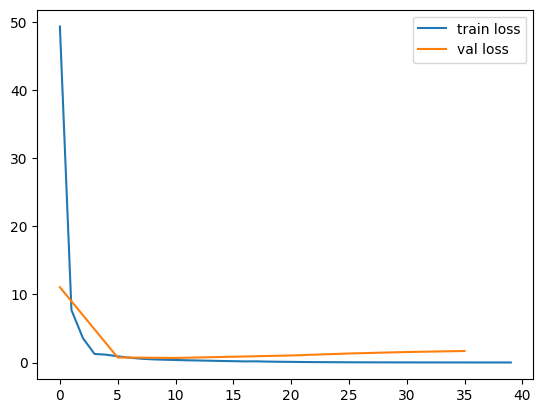

In [21]:
val_freq = 5
n_epochs = 40
model, train_loss, val_loss = train_medmnist(model, train_dataloader,
                                             val_dataloader, optimizer,
                                             epochs=n_epochs, val_freq=val_freq)

### Τι έχει μάθει το CNN;

Είδαμε παραπάνω τι μπορούν να αναγνωρίσουν συγκεκριμένοι πυρήνες σε μια εικόνα. Αλλά τι έχει βρει ο αλγόριθμος του πυρήνα μας για να ταξινομήσει μεταξύ υγιών και ασθενών πνευμόνων; Παρακάτω, βλέπουμε τους πυρήνες του δεύτερου επιπέδου συνελίξεων. Επειδή το πρώτο επίπεδο έχει ήδη εκτελέσει 16 συνελίξεις, υπάρχουν 16 διαφορετικά επίπεδα πυρήνων στο δεύτερο επίπεδο. Μπορείτε να τα δείτε όλα τροποποιώντας τη μεταβλητή <kbd>input_index</kbd>.

/tmp/ipykernel_10536/984550202.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


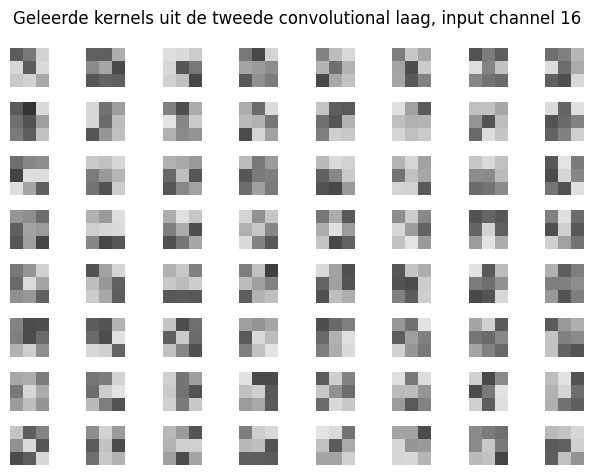

In [22]:
input_index = 16
fig, axs = plt.subplots(8,8, layout='constrained')
for i in range(64):
    kernel = model.conv2.weight[i,input_index,:,:].detach().cpu().numpy()
    cur_ax = np.unravel_index(i, [8,8])
    s = axs[cur_ax].imshow(kernel, clim=[-0.1,0.1],cmap = 'Greys')
    axs[cur_ax].axis('off')
plt.suptitle(f'Geleerde kernels uit de tweede convolutional laag, input channel {input_index}')
plt.tight_layout()
plt.show()

Και εδώ βλέπουμε επίσης τους πυρήνες από το πρώτο στρώμα συνελίξεων.

torch.Size([32, 1, 3, 3])


/tmp/ipykernel_10536/2024605393.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


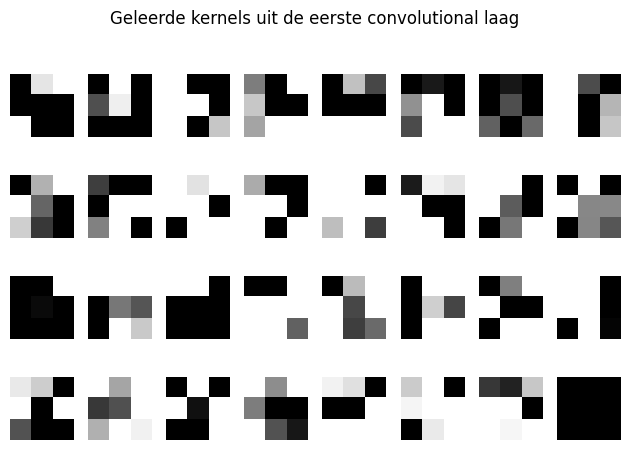

In [23]:
print(np.shape(model.conv1.weight))
fig, axs = plt.subplots(4,8, layout='constrained')
for i in range(32):
    kernel = model.conv1.weight[i,0,:,:].detach().cpu().numpy()
    cur_ax = np.unravel_index(i, [4,8])
    s = axs[cur_ax].imshow(kernel, clim=[-0.1,0.1],cmap = 'Greys')
    axs[cur_ax].axis('off')
plt.suptitle(f'Geleerde kernels uit de eerste convolutional laag')
plt.tight_layout()
plt.show()

## Performance assessment

Τώρα που έχουμε εκπαιδεύσει το μοντέλο, θα εξετάσουμε τον βαθμό στον οποίο μπορεί να κάνει καλές προβλέψεις. Αρχικά, προσδιορίζουμε την ανάκληση και την ακρίβεια του μοντέλου. Η ανάκληση μας λέει πόσα από τα θετικά δεν εντοπίζονται από το μοντέλο (ψευδώς αρνητικά). Η ακρίβεια μετρά πόσα από τα θετικά ταξινομημένα δείγματα είναι στην πραγματικότητα θετικά δείγματα (ψευδώς θετικά). Ποιο μέτρο είναι πιο σημαντικό εξαρτάται από το πρόβλημα. Για παράδειγμα, κατά την ανίχνευση μιας εξαιρετικά σπάνιας μορφής καρκίνου, προτιμάτε μια υψηλή ανάκληση και αποδέχεστε μια χαμηλότερη ακρίβεια ως αποτέλεσμα. Είναι καλύτερο να ανιχνεύετε τα πραγματικά θετικά και να τα χρησιμοποιείτε για να φιλτράρετε τα ψευδώς θετικά σε μια μελέτη παρακολούθησης, αντί να χάνετε εντελώς τα θετικά.

Χρησιμοποιούμε το σύνολο δεδομένων δοκιμής (όχι το σύνολο δεδομένων επικύρωσης) για να προσδιορίσουμε αυτές τις μετρήσεις.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/Precisionrecall.svg/525px-Precisionrecall.svg.png)

Πριν προσδιορίσουμε αυτές τις μετρήσεις, ας δούμε πρώτα μερικά αποτελέσματα του μοντέλου.


In [24]:
def validation_results_visualize(model, dataset):
    index = np.random.randint(0, len(dataset))
    sample = dataset[index]

    small_image = sample['img']
    label = sample['label']
    orig_img = sample['orig']

    plt.imshow(orig_img, cmap='gray')
    plt.yticks([]); plt.xticks([])

    # convert to tensor
    image_t = torch.tensor(small_image).float().to('cuda') # shape (1,28,28)

    with torch.no_grad():
         output = torch.sigmoid(model(image_t.unsqueeze(0))).item()
         print(index)
         plt.title(f"Πραγματική τιμή: {label}, πιθανότητα απονεύρωσης :{output:.3f}, πρόβλεψη CNN: {int(output >= 0.5)}")
         plt.show()

11


/tmp/ipykernel_10536/715730075.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])
/tmp/ipykernel_10536/3698399905.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image_t = torch.tensor(small_image).float().to('cuda') # shape (1,28,28)


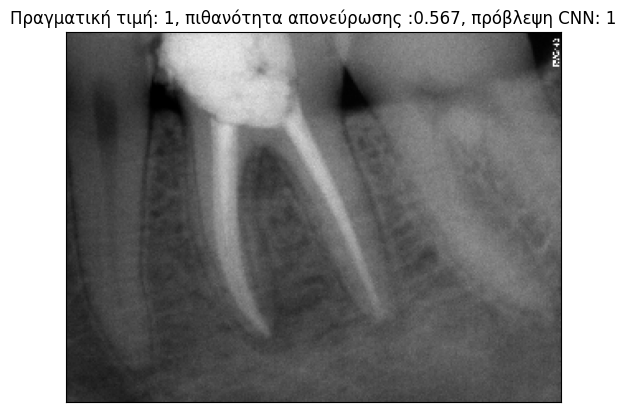

In [25]:
validation_results_visualize(model, test_dataset)

7


/tmp/ipykernel_10536/715730075.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])
/tmp/ipykernel_10536/3698399905.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image_t = torch.tensor(small_image).float().to('cuda') # shape (1,28,28)


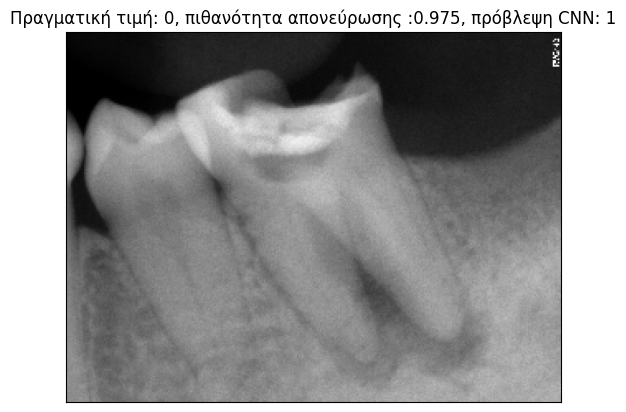

25


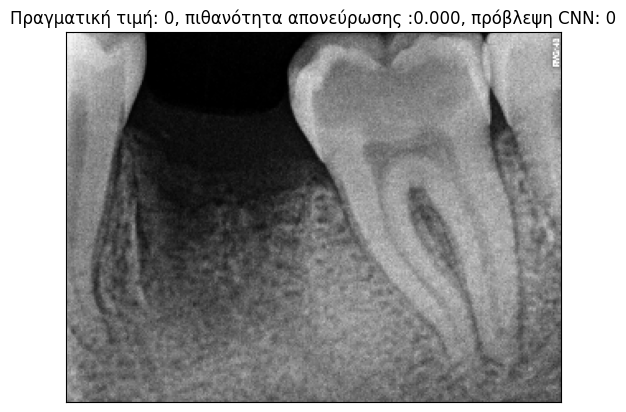

29


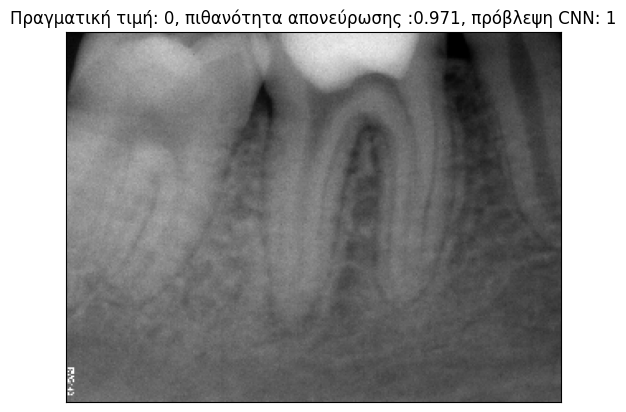

26


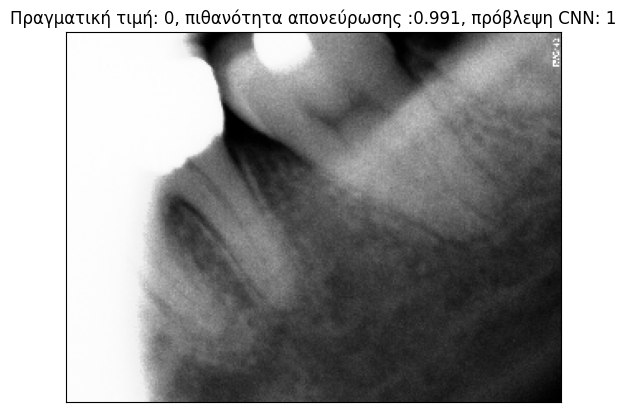

18


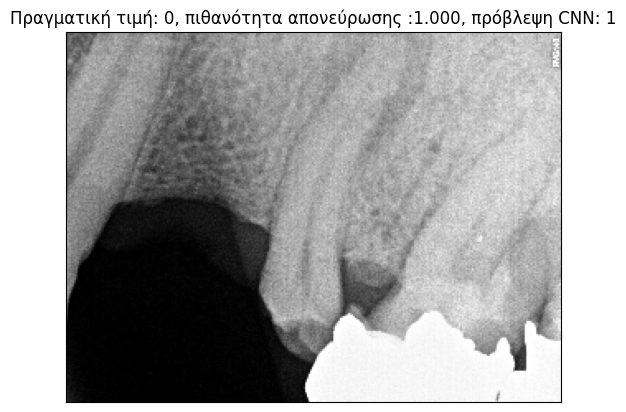

27


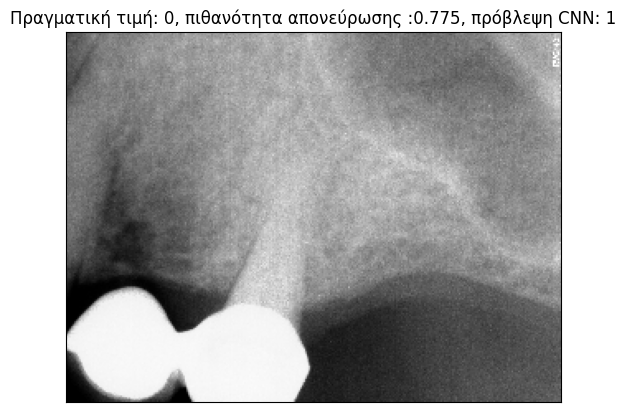

12


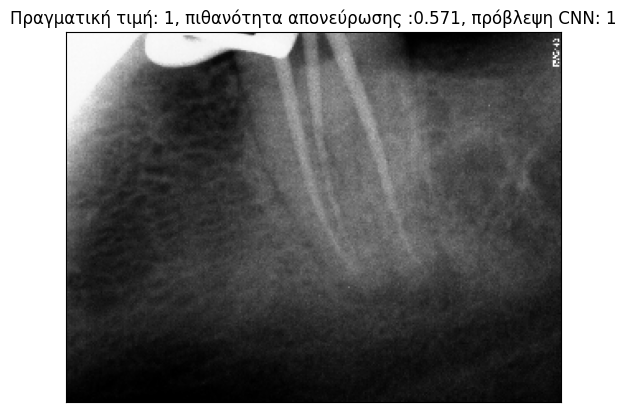

17


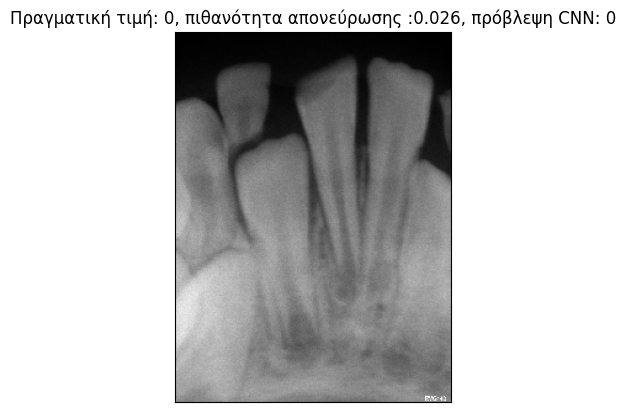

2


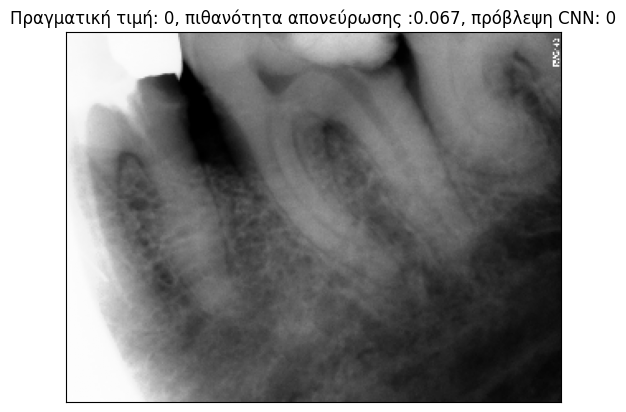

1


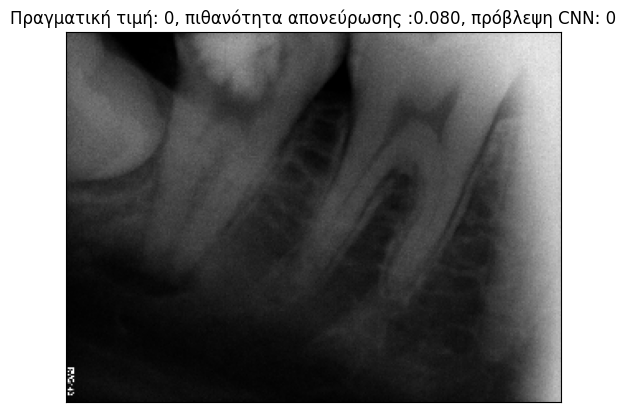

In [26]:
for i in range(10):
    validation_results_visualize(model, test_dataset)

### Υπολογισμός precision και recall

In [27]:

def get_precision_recall(model, dataloader):
    model.eval()
    TP, TN, FP, FN = 0, 0, 0, 0

    with torch.no_grad():
         for batch in dataloader:
             images = batch['img'].float().to('cuda') # (B,1,28,28)
             labels = batch['label'].float().to('cuda') # (B,)
             labels = labels.unsqueeze(1) # (B,1)
             outputs = torch.sigmoid(model(images)) # (B,1)
             preds = (outputs >= 0.5).float() # (B,1)
             TP += ((preds == 1) & (labels == 1)).sum().item()
             TN += ((preds == 0) & (labels == 0)).sum().item()
             FP += ((preds == 1) & (labels == 0)).sum().item()
             FN += ((preds == 0) & (labels == 1)).sum().item()

    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)

    return precision, recall

    test_dataset = TeethMNIST(split="test",transform=data_transform)
test_loader = monai.data.DataLoader(test_dataset, batch_size = 32, shuffle=False,
                                    collate_fn=collate_without_orig)

precision, recall = get_precision_recall(model, test_loader)
print(f'Το precision του μοντέλου είναι {precision:.2f}, το recall του μοντέλου είναι {recall:.2f}.')

### Ο πίνακας σύγχυσης (confusion matrix)


Παρακάτω μπορείτε να δείτε έναν λεγόμενο «πίνακα σύγχυσης». Πόσες περιπτώσεις απονεύρωσης έχουν παραβλεφθεί; Και πόσο συχνά ένας ασθενής διαγιγνώσκεται λανθασμένα; Τι εικόνα δίνει αυτό για το πόσο ισχυρό είναι το μοντέλο; Μπορείτε επίσης να προσδιορίσετε εάν το μοντέλο λειτουργεί καλά στο σύνολο δεδομένων επικύρωσης;

/tmp/ipykernel_10536/715730075.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


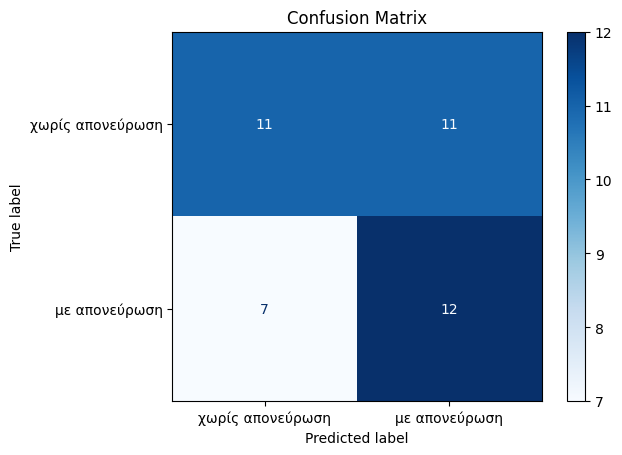

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model,dataloader):
    """
    Plots a confusion matrix using true and predicted labels.

    :param y_true: List or array of true labels.
    :param y_pred: List or array of predicted labels.
    :param labels: List of label names (optional).
    """
    model.eval()
    true_labels = []
    predicted_labels = []


    for data in dataloader:
        images = data['img'].float().to('cuda')
        labels = data['label'].cpu().numpy()
        with torch.no_grad():
            output = torch.sigmoid(model(images)).cpu().numpy().flatten()
        pred_classes = (output >= 0.5).astype(int)
        true_labels.extend(labels)
        predicted_labels.extend(pred_classes)

    cm = confusion_matrix(true_labels, predicted_labels, labels=[0,1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['χωρίς απονεύρωση', 'με απονεύρωση'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(model, test_loader)

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()

        self.gradients = None
        self.activations = None

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_backward_hook(backward_hook)

    def generate(self, input_tensor):
        output = self.model(input_tensor)
        self.model.zero_grad()
        output.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze()

        cam = cam.cpu().numpy()
        cam = np.maximum(cam, 0)
        cam = cam / cam.max()

        return cam

def visualize_gradcam(model, dataset, index, device='cuda'):
    sample = dataset[index]

    small_img = sample['img'].unsqueeze(0).float().to(device)
    orig_img = sample['orig']
    label = sample['label']

    gradcam = GradCAM(model, model.conv2)
    cam = gradcam.generate(small_img)

    cam_resized = cv2.resize(cam, (orig_img.shape[1], orig_img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = 0.4 * heatmap + 0.6 * np.stack([orig_img]*3, axis=-1)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(orig_img, cmap='gray')
    plt.title(f"Original (label={label})")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(overlay.astype(np.uint8))
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.show()

/tmp/ipykernel_10536/715730075.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


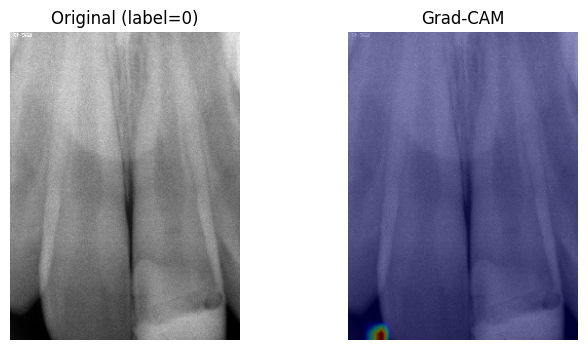

In [31]:
visualize_gradcam(model, test_dataset, 10, device='cuda')